# Noisy GPG: infidelity versus cooperativity

This notebook plots the noisy-GPG recovered infidelity versus cooperativity for the two clean AD probabilities
\(p=5\times 10^{-4}\) and \(p=5\times 10^{-3}\).

The optimization results and pulse sequences are loaded from `datas/noisy_gpgs_pulses`; this notebook does not rerun the pulse search.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "python" / "codes").exists())
metrics_path = repo_root / "datas" / "noisy_gpgs_pulses" / "metrics.csv"
fig_dir = repo_root / "plots" / "AD"
fig_dir.mkdir(parents=True, exist_ok=True)


In [20]:
P_VALUES = np.array([5e-4, 5e-3], dtype=float)
COOPERATIVITIES = np.array([1e6, 1e7, 1e8, 1e9, 1e10], dtype=float)

metrics = pd.read_csv(metrics_path)

p_mask = np.logical_or.reduce([np.isclose(metrics["p"], p) for p in P_VALUES])
c_mask = np.logical_or.reduce([np.isclose(metrics["cooperativity"], C) for C in COOPERATIVITIES])

plot_data = (
    metrics.loc[p_mask & c_mask]
    .sort_values(["p", "cooperativity"])
    .reset_index(drop=True)
)
plot_data["monotonic_violation"] = plot_data.groupby("p")["gpg_infidelity"].diff().gt(0)

expected_points = len(P_VALUES) * len(COOPERATIVITIES)
if len(plot_data) != expected_points:
    print(f"Warning: expected {expected_points} points, found {len(plot_data)}.")

display(
    plot_data[
        [
            "p",
            "cooperativity",
            "exact_infidelity",
            "gpg_infidelity",
            "gpg_minus_exact_infidelity_penalty",
            "max_state_prep_infidelity",
            "monotonic_violation",
        ]
    ]
)


,p,cooperativity,exact_infidelity,gpg_infidelity,gpg_minus_exact_infidelity_penalty,max_state_prep_infidelity,monotonic_violation
0,0.0005,1.000000e+06,3.609277e-08,0.001129,0.001129,0.100267,False
1,0.0005,1.000000e+07,3.609277e-08,0.000225,0.000225,0.026663,False
2,0.0005,1.000000e+08,3.609277e-08,0.000041,0.000041,0.014376,False
3,0.0005,1.000000e+09,3.609277e-08,0.000021,0.000021,0.005147,False
4,0.0005,1.000000e+10,3.609277e-08,0.000006,0.000006,0.001915,False
5,0.0050,1.000000e+06,7.251900e-07,0.003257,0.003256,0.100803,False
6,0.0050,1.000000e+07,7.251900e-07,0.000523,0.000522,0.030639,False
7,0.0050,1.000000e+08,7.251900e-07,0.000075,0.000074,0.014757,False
8,0.0050,1.000000e+09,7.251900e-07,0.000036,0.000035,0.005249,False
9,0.0050,1.000000e+10,7.251900e-07,0.000010,0.000009,0.002315,False


<repo-root>/plots/AD/noisy_gpg_cooperativity_sweep_p5e-4_p5e-3_main.pdf
<repo-root>/plots/AD/noisy_gpg_cooperativity_sweep_p5e-4_p5e-3_main.png


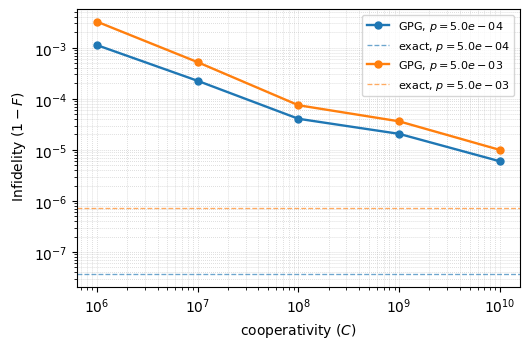

In [24]:
fig, ax = plt.subplots(figsize=(5.4, 3.6))

for p_value, group in plot_data.groupby("p"):
    group = group.sort_values("cooperativity")
    line = ax.loglog(
        group["cooperativity"],
        group["gpg_infidelity"],
        "o-",
        lw=1.7,
        ms=5,
        label=rf"GPG, $p={p_value:.1e}$",
    )[0]
    ax.axhline(
        group["exact_infidelity"].iloc[0],
        color=line.get_color(),
        ls="--",
        lw=0.95,
        alpha=0.65,
        label=rf"exact, $p={p_value:.1e}$",
    )

ax.set_xlabel(r"cooperativity $(C)$")
ax.set_ylabel(r" Infidelity $(1-F)$")
#ax.set_title(r"Noisy GPG cooperativity sweep")
ax.grid(True, which="both", ls=":", lw=0.55, alpha=0.65)
ax.legend(frameon=True, fontsize=8)
fig.tight_layout()

pdf_path = fig_dir / "noisy_gpg_cooperativity_sweep_p5e-4_p5e-3_main.pdf"
png_path = fig_dir / "noisy_gpg_cooperativity_sweep_p5e-4_p5e-3_main.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=240, bbox_inches="tight")

print(pdf_path)
print(png_path)
plt.show()
